In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kaushalvaid/celegan-all-phases/celeba_32x32_gray.pt
/kaggle/input/datasets/kaushalvaid/celegan-all-phases/celeba_64x64_hr.pt
/kaggle/input/datasets/kaushalvaid/celegan-all-phases/celeba_16x16_lr.pt


### Imports

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset
from torchvision import transforms, datasets
import torch.optim as optim
import random

from tqdm import tqdm

import os
import matplotlib.pyplot as plt
import torchvision.utils as vutils

### Model

In [3]:
def weight_init(m):
    """
        DCGAN paper: init Conv and BatchNorm weights from Normal(0, 0.02) and Normal (1.0, 0.02) respectively.
        Called once on G and D after instantiation.
    """
    classname = m.__class__.__name__

    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    """
        Input: (B, z_dim, 1, 1)
        Output: (B, 3, 64, 64)
    """

    def __init__(self, z_dim=100, features_g=64):
        super().__init__()

        # features_g is the base channel multiplier 
        self.net = nn.Sequential(
            # (B, z_dim, 1, 1) --> (B, features_g*8, 4, 4)
            self._block(z_dim, features_g * 8, kernel=4, stride=1, padding=0),

            # (B, fg*8, 4, 4) --> (B, fg*4, 8, 8)
            self._block(features_g * 8, features_g * 4, kernel=4, stride=2, padding=1),

            # (B, fg*4, 8, 8) --> (B, fg*2, 16, 16)
            self._block(features_g * 4, features_g * 2, kernel=4, stride=2, padding=1),

            # (B, fg*2, 16, 16) --> (B, fg, 32, 32)
            self._block(features_g * 2, features_g, kernel=4, stride=2, padding=1),

            # output layer -- no batchNorm
            # (B, fg, 32, 32) --> (B, 3, 64, 64)
            nn.ConvTranspose2d(features_g, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def _block(self, in_channels, out_channels, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=kernel,
                stride=stride,
                padding=padding,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True) # G uses ReLu and not LeakyReLU
        )

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    """
        Input: (B, 3, 64, 64)
        Output: (B, 1, 1, 1) --> squeezed to (B, 1)
    """

    def __init__(self, features_d=64):
        super().__init__()

        self.net = nn.Sequential(
            # (B, 3, 64, 64) --> (B, fd, 32, 32)
            nn.Conv2d(3, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (B, fd, 32, 32) --> (B, fd*2, 16, 16)
            self._block(features_d, features_d * 2, kernel=4, stride=2, padding=1),

            # (B, fd*2, 16, 16) --> (B, fd*4, 8, 8)
            self._block(features_d * 2, features_d * 4, kernel=4, stride=2, padding=1),

            # (B, fd*4, 8, 8) --> (B, fd*8, 4, 4)
            self._block(features_d * 4, features_d * 8, kernel=4, stride=2, padding=1),

            # output layer
            # (B, fd*8, 4, 4) --> (B, 1, 1, 1)
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )
    
    def _block(self, in_channels, out_channels, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel,
                stride=stride,
                padding=padding,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True), # D uses LeakyReLU
        )
    
    def forward(self, x):
        return self.net(x).view(x.size(0), -1) # (B, 1, 1, 1) --> (B, 1)

# sanity check
if __name__ == "__main__":
    G = Generator(z_dim=100, features_g=64)
    D = Discriminator(features_d=64)

    z = torch.randn(4, 100, 1, 1)
    fake = G(z)
    out = D(fake)

    print("G output:", fake.shape)   # expect (4, 3, 64, 64)
    print("D output:", out.shape)    # expect (4, 1)
    print("D range:", out.min().item(), out.max().item())  # expect ~(0, 1)


G output: torch.Size([4, 3, 64, 64])
D output: torch.Size([4, 1])
D range: 0.4084092378616333 0.6017102599143982


### Utils - Helper functions

In [4]:
def save_image_grid(fake_samples, epoch, path="outputs/"):
    """
        Saves a grid of generated images to disk.
        fake_samples: (B, 1, H, W) tensor in [-1, 1]
    """

    os.makedirs(path, exist_ok=True)

    # denormalise for display
    fake_samples = (fake_samples + 1) / 2

    grid = vutils.make_grid(fake_samples, nrow=8, padding=2, normalize=False)
    grid_np = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(grid_np)
    plt.axis("off")
    plt.title(f"Epoch {epoch}")
    plt.tight_layout()
    plt.savefig(os.path.join(path, f"epoch_{epoch:03d}.png"), dpi=100)
    plt.close()

def plot_loss_curve(loss_G, loss_D, path="outputs/"):
    """
        Saves G and D loss curves across epochs.
    """
    os.makedirs(path, exist_ok=True)

    plt.figure(figsize=(10, 4))
    plt.plot(loss_G, label="Generator Loss", color="steelblue")
    plt.plot(loss_D, label="Discriminator Loss", color="tomato")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(path, "loss_curve.png"), dpi=100)
    plt.close()

def load_and_display_progression(output_dir, epochs):
    """
        Notebook-only function.
        Loads saved grids from disk and plots them side by side for visual progression.
        epochs: e.g. [1, 5, 10, 25, 50]
    """
    fig, axes = plt.subplots(1, len(epochs), figsize=(4 * len(epochs), 4))

    for ax, epoch in zip(axes, epochs):
        img_path = os.path.join(output_dir, f"epoch_{epoch:03d}.png")
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.suptitle("GAN Progression", fontsize=14)
    plt.tight_layout()
    plt.show()

### Dataset DataLoader

In [5]:
def get_celeba_loader(
    root,
    image_size,
    batch_size,
    num_workers=0,
    max_samples=20000
):
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    full_dataset = datasets.ImageFolder(root=root, transform=transform)

    indices = random.sample(range(len(full_dataset)), min(max_samples, len(full_dataset)))
    dataset = Subset(full_dataset, indices)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True
    )

def get_tensor_loader(pt_path, batch_size):
    tensor = torch.load(pt_path, weights_only=True) # shape: (N, C, H, W)
    dataset = TensorDataset(tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )

class FakeDataset(Dataset):
    def __init__(self, num_samples=1000, image_size=64):
        super().__init__()

        self.num_samples = num_samples
        self.image_size = image_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return torch.randn(3, self.image_size, self.image_size), 0


def get_fake_loader(batch_size, image_size=64):
    dataset = FakeDataset(num_samples=1000, image_size=image_size)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

### Training

In [7]:
# hyperparameters
IMAGE_SIZE = 64
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LR = 2e-4
Z_DIM = 100
FEATURES_G = 64
FEATURES_D = 64
IMAGE_DIM = 64 * 64 * 3 # 12288
NUM_EPOCHS = 50
SAVE_EPOCHS = [1, 5, 10, 25, 50]
IS_KAGGLE = torch.cuda.is_available()
PT_PATH = "/kaggle/input/datasets/kaushalvaid/celegan-all-phases/celeba_64x64_hr.pt"

def train():
    # data
    if IS_KAGGLE and PT_PATH:
        loader = get_tensor_loader(pt_path=PT_PATH, batch_size=BATCH_SIZE)
    else:
        loader = get_fake_loader(batch_size=BATCH_SIZE, image_size=IMAGE_SIZE)

    # model
    G = Generator(z_dim=Z_DIM, features_g=FEATURES_G).to(DEVICE)
    D = Discriminator(features_d=FEATURES_D).to(DEVICE)
    G.apply(weight_init)
    D.apply(weight_init)

    # optims
    opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

    # loss
    criterion = nn.BCELoss()

    # fixed noise
    fixed_noise = torch.randn(64, Z_DIM, 1, 1).to(DEVICE)

    loss_G_history = []
    loss_D_history = []

    # training
    print("--------------- Starting training ---------------")

    for epoch in range(1, NUM_EPOCHS+1):
        loss_G_epoch = 0.0
        loss_D_epoch = 0.0

        for batch_idx, (real,) in enumerate(tqdm(loader, desc=f"Epoch [{epoch}/{NUM_EPOCHS}]", leave=True)):
            
            real = real.to(DEVICE) # shape stays (B, 3, 64, 64)
            B = real.size(0)

            # train D
            noise = torch.randn(B, Z_DIM, 1, 1).to(DEVICE)
            fake = G(noise).detach()

            real_labels = torch.ones(B, 1).to(DEVICE)
            fake_labels = torch.zeros(B, 1).to(DEVICE)

            loss_D_real = criterion(D(real), real_labels)
            loss_D_fake = criterion(D(fake), fake_labels)

            loss_D = loss_D_fake + loss_D_real

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # train G
            noise = torch.randn(B, Z_DIM, 1, 1).to(DEVICE)
            fake = G(noise)

            loss_G = criterion(D(fake), real_labels)

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            loss_D_epoch += loss_D.item()
            loss_G_epoch += loss_G.item()

        # end of epoch
        avg_G = loss_G_epoch / len(loader)
        avg_D = loss_D_epoch / len(loader)
        loss_G_history.append(avg_G)
        loss_D_history.append(avg_D)

        print(f"Epoch [{epoch}/{NUM_EPOCHS}] | loss_D: {avg_D:.4f} | loss_G: {avg_G:.4f}")

        if epoch in SAVE_EPOCHS:
            with torch.no_grad():
                sample = G(fixed_noise)
                save_image_grid(sample, epoch, path="outputs/")

    plot_loss_curve(loss_G_history, loss_D_history, path="outputs/")



# calling train
train()


--------------- Starting training ---------------


Epoch [1/50]: 100%|██████████| 390/390 [01:09<00:00,  5.58it/s]


Epoch [1/50] | loss_D: 0.6337 | loss_G: 8.3543


Epoch [2/50]: 100%|██████████| 390/390 [01:13<00:00,  5.27it/s]


Epoch [2/50] | loss_D: 0.6511 | loss_G: 4.9499


...

Epoch [48/50] | loss_D: 0.4780 | loss_G: 3.2865


Epoch [49/50]: 100%|██████████| 390/390 [01:12<00:00,  5.35it/s]


Epoch [49/50] | loss_D: 0.2259 | loss_G: 3.6361


Epoch [50/50]: 100%|██████████| 390/390 [01:12<00:00,  5.35it/s]


Epoch [50/50] | loss_D: 0.5188 | loss_G: 3.2886


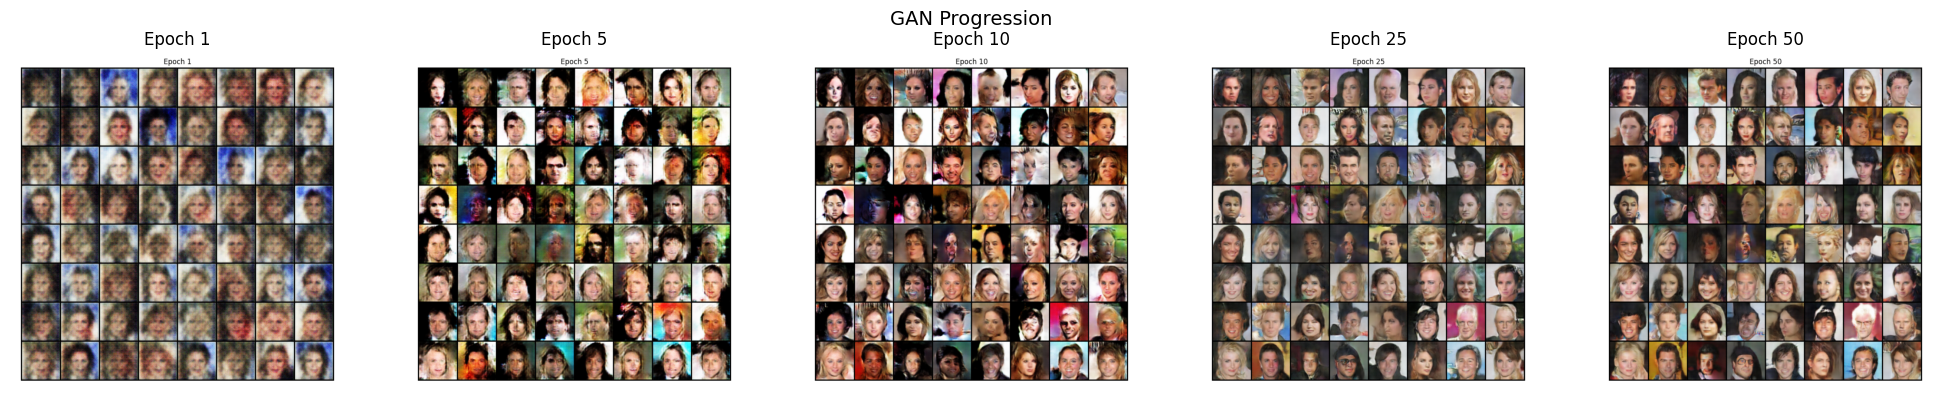

In [8]:
load_and_display_progression(output_dir='/kaggle/working/outputs', epochs=[1, 5, 10, 25, 50])

### Observations

- **Epoch 1**: already recognizable faces with color, hair, rough facial structure — Vanilla GAN took until epoch 10 to get here
- **Epoch 5→10**: sharpening rapidly, diverse skin tones, hair colors, backgrounds emerging
- **Epoch 25→50**: faces are photorealistic at a glance. Individual samples have clear identity, lighting, expression variation. The MLP ceiling is completely gone.

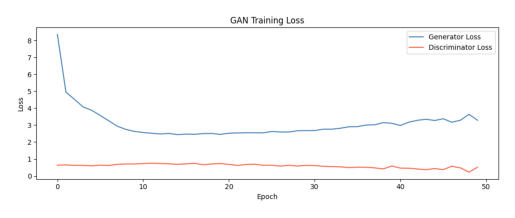

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/kaggle/working/outputs/loss_curve.png')
plt.imshow(img)
plt.axis('off') # Optional: hides grid lines and pixel counts
plt.show()

### Observations

- one **RED FLAG** -- at ending epochs, the D is clearly dominating (loss around 0.3ish) with 0.22 at epoch 49
- If i had ran 100 epochs, loss_D would collapse towardss 0 and G's images would degrade -- instability

### Improvements
- We can add LR scheduler
- Spectral Normalization on D
- train G twice per D step to balance.

### Interpretation of Loss
- loss_G settling at **~3.2-3.3** is higher than Vanilla GAN (~1.0) -- counterintuitive
- Higher loss_G means D is harder to fool, which means D is more capable, means G is being pushed harder to improve.
- The better the D, the higher G's loss at equilibrium
